# METR-LA Traffic Network with KoopmanGraph

This notebook applies **KoopmanGraph** to the **METR-LA** benchmark — a standard
traffic forecasting dataset from Los Angeles County loop detectors. We use the
real DCRNN road-network graph and a window of measured traffic speeds, then
train a topology-aware Koopman model to forecast future speeds.

## Domain context (for non-experts)

A highway sensor network is a graph:

- **Sensors (nodes)** are loop detectors embedded in pavement that measure
  traffic speed every five minutes.
- **Road segments (edges)** connect nearby sensors when vehicles can flow
  between them on the freeway network.

Each node carries one feature in this tutorial:

| Feature | Meaning |
|---------|---------|
| **Speed** | Average traffic speed (mph), z-score normalized over the cached window |

Congestion at one sensor propagates to neighbors over time — a classic
**spatiotemporal graph dynamics** problem. KoopmanGraph respects that topology
during encoding and decoding, unlike methods that flatten all sensors into one
long vector.

## The encode → Koopman step → decode workflow

1. **Encode:** A GNN lifts per-sensor speed into a latent space while
   respecting the road-network adjacency.
2. **Koopman step:** A learned matrix $K$ advances latent states linearly:
   $z_{t+1} \approx z_t K^\top$.
3. **Decode:** A GNN maps latent states back to physical speed predictions.

We compare this graph-aware model against a **vectorized Koopman baseline** that
flattens all sensor speeds into one state vector and applies a single linear
Koopman map — the standard approach when topology is ignored.

In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os

import matplotlib

# Agg is required for headless nbmake/CI runs; interactive kernels use inline.
if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

import torch
from torch import nn

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.datasets import MetrLaTrafficBenchmark
from koopman_graph.operator import KoopmanOperator
from koopman_graph.training import constant_loss_weights

## Load METR-LA data

Speed readings and graph metadata come from the
[DCRNN METR-LA release](https://github.com/liyaguang/DCRNN). KoopmanGraph ships
a small cached subset under `data/metr_la/traffic.pt` (60 timesteps, 207
sensors) so this notebook runs offline.

Missing loop-detector readings are stored as **0** in the HDF5 file. The cache
builder imputes those values (forward/backward fill per sensor) before
z-score normalization so trajectories do not show artificial spikes.

**Full dataset acquisition:**

1. Download `metr-la.h5` from the
   [DCRNN Google Drive](https://drive.google.com/open?id=10FOTa6HXPqX8Pf5WRoRwcFnW9BrNZEIX)
   or the public Hugging Face mirror documented in the download script.
2. Rebuild the cache:

```bash
python scripts/download_metr_la.py --h5-path /path/to/metr-la.h5 --force
# or fetch the mirror automatically:
python scripts/download_metr_la.py --fetch-h5 /tmp/metr-la.h5 --force
```

Road-network distances and sensor IDs are fetched from the DCRNN GitHub
repository when the cache is built.

In [2]:
topology = MetrLaTrafficBenchmark.load_topology()
data_sequence = MetrLaTrafficBenchmark.load_sequence()

print(f"Sensors: {topology['num_nodes']}")
print(f"Road edges (directed): {topology['edge_index'].shape[1]}")
print(f"Snapshots: {data_sequence.num_timesteps}")
print(f"Feature dim: {data_sequence.in_channels}")
print(f"First snapshot shape: {data_sequence[0].x.shape}")

Sensors: 207
Road edges (directed): 3444
Snapshots: 60
Feature dim: 1
First snapshot shape: torch.Size([207, 1])


Plot normalized speed at a few sensors over time.

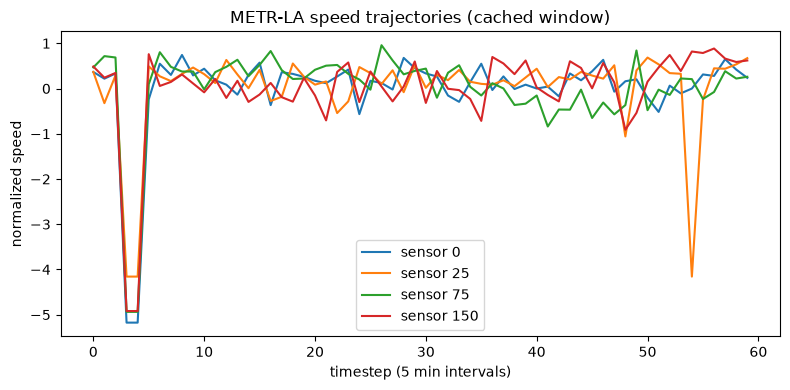

In [3]:
sensor_ids = [0, 25, 75, 150]
times = torch.arange(data_sequence.num_timesteps)

fig, ax = plt.subplots(figsize=(8, 4))
for sensor_id in sensor_ids:
    values = torch.stack([snap.x[sensor_id, 0] for snap in data_sequence])
    ax.plot(times, values.numpy(), label=f"sensor {sensor_id}")
ax.set_xlabel("timestep (5 min intervals)")
ax.set_ylabel("normalized speed")
ax.set_title("METR-LA speed trajectories (cached window)")
ax.legend()
fig.tight_layout()
plt.show()

## Build the graph Koopman model

We use a GCN encoder/decoder sized for one speed feature on 207 sensors.

In [4]:
in_channels = data_sequence.in_channels
hidden_channels = 64
latent_dim = 64

encoder = GNNEncoder(in_channels, hidden_channels, latent_dim)
decoder = GNNDecoder(latent_dim, hidden_channels, in_channels)
model = GraphKoopmanModel(
    encoder=encoder,
    decoder=decoder,
    latent_dim=latent_dim,
    time_step=5.0,
)

print(model)

GraphKoopmanModel(
  (encoder): GNNEncoder(
    (activation): ReLU()
    (convs): ModuleList(
      (0): GCNConv(1, 64)
      (1): GCNConv(64, 64)
    )
  )
  (decoder): GNNDecoder(
    (activation): ReLU()
    (convs): ModuleList(
      (0): GCNConv(64, 64)
      (1): GCNConv(64, 1)
    )
  )
  (koopman): KoopmanOperator()
)


## Train the graph model

`fit` optimizes one-step reconstruction, forward consistency, and an
autoregressive rollout term that matches `predict`. A higher rollout weight
helps multi-step speed forecasts on all 207 sensors.

In [5]:
predict_steps = 10
loss_weights = constant_loss_weights(
    reconstruction=1.0,
    forward=1.0,
    rollout=3.0,
)

torch.manual_seed(0)
history = model.fit(
    data_sequence,
    epochs=200,
    lr=1e-3,
    loss_weights=loss_weights,
    rollout_horizon=predict_steps,
    max_grad_norm=1.0,
)

print(f"Initial loss: {history.loss[0]:.6f}")
print(f"Final loss: {history.loss[-1]:.6f}")

Initial loss: 15.872677
Final loss: 2.781341


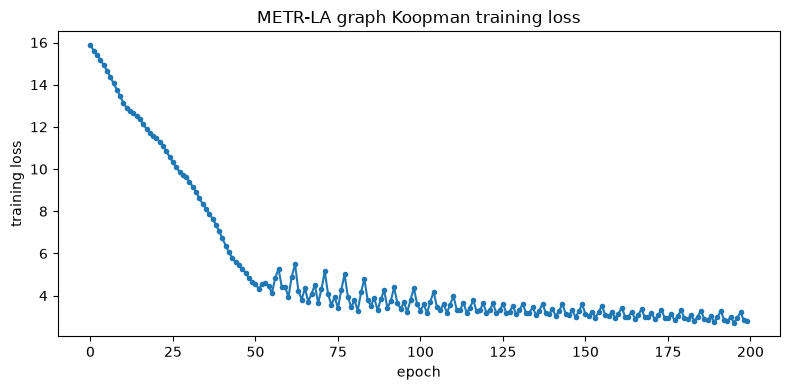

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.loss, marker="o", markersize=3)
ax.set_xlabel("epoch")
ax.set_ylabel("training loss")
ax.set_title("METR-LA graph Koopman training loss")
fig.tight_layout()
plt.show()

## Predict future speeds (graph model)

`predict` rolls out autoregressively in latent space and decodes after each step.

In [7]:
initial_graph = data_sequence[0]
future_graphs = model.predict(initial_graph, steps=predict_steps)

ground_truth = data_sequence[1 : predict_steps + 1]
graph_mse = torch.mean(
    torch.stack(
        [
            torch.mean((pred.x - truth.x) ** 2)
            for pred, truth in zip(future_graphs, ground_truth, strict=True)
        ]
    )
)
print(f"Graph Koopman rollout MSE: {graph_mse.item():.6f}")

Graph Koopman rollout MSE: 0.684050


## Vectorized Koopman baseline

A classical Koopman pipeline ignores graph structure: all sensor speeds are
concatenated into one vector $v_t \in \mathbb{R}^{N}$ and advanced with a
single linear operator $v_{t+1} \approx v_t K^\top$.

We train this baseline on the same one-step MSE objective and compare rollout
error. The graph model typically benefits when congestion patterns propagate
along the road network rather than arbitrary index order.

In [8]:
class VectorizedKoopmanBaseline(nn.Module):
    """Flatten node features and apply one shared Koopman linear map."""

    def __init__(self, state_dim: int) -> None:
        super().__init__()
        self.state_dim = state_dim
        self.operator = KoopmanOperator(state_dim)

    def flatten(self, x: torch.Tensor) -> torch.Tensor:
        return x.reshape(-1)

    def unflatten(self, vector: torch.Tensor, num_nodes: int) -> torch.Tensor:
        return vector.reshape(num_nodes, -1)

    def predict_step(self, x: torch.Tensor) -> torch.Tensor:
        vector = self.flatten(x).unsqueeze(0)
        next_vector = self.operator(vector).squeeze(0)
        return self.unflatten(next_vector, x.shape[0])


state_dim = data_sequence.num_nodes * data_sequence.in_channels
baseline = VectorizedKoopmanBaseline(state_dim)
optimizer = torch.optim.Adam(baseline.parameters(), lr=1e-3)

torch.manual_seed(0)
for _ in range(200):
    optimizer.zero_grad()
    loss_terms = []
    for left, right in zip(data_sequence[:-1], data_sequence[1:], strict=True):
        pred = baseline.predict_step(left.x)
        loss_terms.append(torch.mean((pred - right.x) ** 2))
    loss = torch.stack(loss_terms).mean()
    loss.backward()
    nn.utils.clip_grad_norm_(baseline.parameters(), 1.0)
    optimizer.step()

baseline.eval()
with torch.no_grad():
    state = data_sequence[0].x
    baseline_preds = []
    for _ in range(predict_steps):
        state = baseline.predict_step(state)
        baseline_preds.append(state)

baseline_mse = torch.mean(
    torch.stack(
        [
            torch.mean((pred - truth.x) ** 2)
            for pred, truth in zip(baseline_preds, ground_truth, strict=True)
        ]
    )
)

print(f"Vectorized Koopman rollout MSE: {baseline_mse.item():.6f}")
print(f"Graph Koopman rollout MSE:      {graph_mse.item():.6f}")
if graph_mse < baseline_mse:
    print("Graph model wins on this cached window (lower MSE).")
else:
    print("Vectorized baseline wins on this cached window (lower MSE).")

Vectorized Koopman rollout MSE: 4.695334
Graph Koopman rollout MSE:      0.684050
Graph model wins on this cached window (lower MSE).


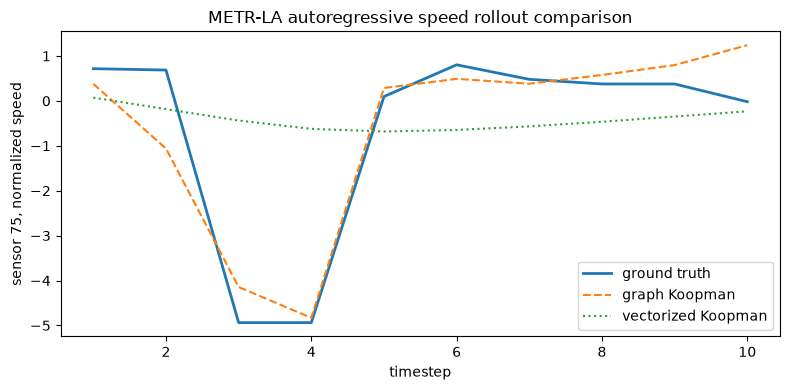

In [9]:
sensor_id = 75
graph_values = torch.stack([graph.x[sensor_id, 0] for graph in future_graphs])
baseline_values = torch.stack([pred[sensor_id, 0] for pred in baseline_preds])
truth_values = torch.stack([graph.x[sensor_id, 0] for graph in ground_truth])
pred_times = torch.arange(1, predict_steps + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pred_times, truth_values.numpy(), label="ground truth", linewidth=2)
ax.plot(pred_times, graph_values.numpy(), label="graph Koopman", linestyle="--")
ax.plot(pred_times, baseline_values.numpy(), label="vectorized Koopman", linestyle=":")
ax.set_xlabel("timestep")
ax.set_ylabel(f"sensor {sensor_id}, normalized speed")
ax.set_title("METR-LA autoregressive speed rollout comparison")
ax.legend()
fig.tight_layout()
plt.show()

## Next steps

- See [`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb) for a smaller
  synthetic graph walkthrough.
- See [`02_ieee118_bus.ipynb`](02_ieee118_bus.ipynb) for a smart-grid example
  on the IEEE 118-bus network.
- Explore the [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html)
  for loss weights, early stopping, and GAT encoders.